In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools
import warnings

warnings.filterwarnings("ignore")  # optional: suppress convergence warnings

########################################
# 1. Download data from FRED
########################################

fred = Fred(api_key='30526e65b50be1c2bbd2cc739664acc2')  # keep your key secure
series_id = 'PNFIC1'
data = fred.get_series(series_id)

# Put into DataFrame and ensure datetime index
df = pd.DataFrame(data, columns=[series_id])
df.index = pd.to_datetime(df.index)

# Set to quarterly start frequency (if you want quarterly) and forward-fill missing values
df = df.asfreq('QS')

# Use ffill() instead of fillna(method='ffill') for compatibility
df = df.ffill()

print(df.head())

########################################
# 2. Get the Growth Rate
########################################

# Quarterly growth rate (YoY quarter-over-quarter)
df['GrowthRate'] = df[series_id].pct_change(4).astype(float)

# Drop NaNs before modeling (first few rows will be NaN because of pct_change(4))
growth = df['GrowthRate'].dropna()

########################################
# 3. Grid search to find the best ARMA(p,q)
########################################

p_values = range(0, 5)
q_values = range(0, 5)
pq_combinations = list(itertools.product(p_values, q_values))

best_aic = np.inf
best_order = None
best_model = None

for p, q in pq_combinations:
    try:
        # ARIMA with (p, d=0, q) => ARMA(p,q)
        model = ARIMA(growth, order=(p, 0, q))
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = (p, 0, q)
            best_model = results
    except Exception as e:
        # Print the exception for debugging but continue
        print(f"Failed to fit ARMA({p},{q}): {e}")
        continue

print("Best ARMA order:", best_order)
print("Best AIC:", best_aic)

# Optionally: summary of the best model
if best_model is not None:
    print(best_model.summary())


            PNFIC1
1947-01-01     NaN
1947-04-01     NaN
1947-07-01     NaN
1947-10-01     NaN
1948-01-01     NaN
Best ARMA order: (1, 0, 3)
Best AIC: -334.7093605108508
                               SARIMAX Results                                
Dep. Variable:             GrowthRate   No. Observations:                   71
Model:                 ARIMA(1, 0, 3)   Log Likelihood                 173.355
Date:                Fri, 13 Feb 2026   AIC                           -334.709
Time:                        15:20:22   BIC                           -321.133
Sample:                    01-01-2008   HQIC                          -329.311
                         - 07-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0364      0.023      1.

## b. Estimate an AR(4) model. Report using hetereskedastic-consistent standard errors.

In [6]:
########################################
# 4. Estimate an AR(4) model
########################################

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

# Make sure there are no missing values
df = df.dropna(subset=['GrowthRate'])

# Create lagged variables for AR(4)
df['L1'] = df['GrowthRate'].shift(1)
df['L2'] = df['GrowthRate'].shift(2)
df['L3'] = df['GrowthRate'].shift(3)
df['L4'] = df['GrowthRate'].shift(4)

# Drop NaNs introduced by lagging
df = df.dropna()

# Define dependent (Y) and independent variables (X)
Y = df['GrowthRate']
X = df[['L1', 'L2', 'L3', 'L4']]
X = sm.add_constant(X)  # Add intercept

# Estimate AR(4) using OLS
model = sm.OLS(Y, X).fit(cov_type='HC0')  # Apply HC standard errors
print("=== AR(4) with HC standard errors ===")
print(model.summary())

=== AR(4) with HC standard errors ===
                            OLS Regression Results                            
Dep. Variable:             GrowthRate   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     103.3
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           1.06e-26
Time:                        15:26:13   Log-Likelihood:                 151.29
No. Observations:                  67   AIC:                            -292.6
Df Residuals:                      62   BIC:                            -281.6
Df Model:                           4                                         
Covariance Type:                  HC0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         

# Repeat using Newey-West standard errors using M=5

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Make sure there are no missing values
df = df.dropna(subset=['GrowthRate'])

# Create lagged variables for AR(4)
df['L1'] = df['GrowthRate'].shift(1)
df['L2'] = df['GrowthRate'].shift(2)
df['L3'] = df['GrowthRate'].shift(3)
df['L4'] = df['GrowthRate'].shift(4)

# Drop NaNs introduced by lagging
df = df.dropna()

# Define dependent (Y) and independent variables (X)
Y = df['GrowthRate']
X = df[['L1', 'L2', 'L3', 'L4']]
X = sm.add_constant(X)  # Add intercept

# Estimate AR(4) using OLS with Newey-West (HAC) standard errors (M=5)
model = sm.OLS(Y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})

print("=== AR(4) with Newey-West (HAC) standard errors, M=5 ===")
print(model.summary())

=== AR(4) with Newey-West (HAC) standard errors, M=5 ===
                            OLS Regression Results                            
Dep. Variable:             GrowthRate   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     111.5
Date:                Fri, 13 Feb 2026   Prob (F-statistic):           1.58e-26
Time:                        15:28:30   Log-Likelihood:                 147.79
No. Observations:                  63   AIC:                            -285.6
Df Residuals:                      58   BIC:                            -274.9
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

# Comment on the magnitude and interpretation of the coefficients

# Calculate, numerically, the impulse response function for j = 1, 2, . . . 10.

In [8]:
# Extract AR(4) coefficients from the OLS model
phi = model.params[['L1', 'L2', 'L3', 'L4']].values

# Define the impulse response function (IRF)
horizon = 10  # Compute for j = 1, 2, ..., 10
irf = np.zeros(horizon)

# Compute IRF using recursion
for j in range(horizon):
    if j == 0:
        irf[j] = phi[0]
    elif j == 1:
        irf[j] = phi[0] * irf[j-1] + phi[1]
    elif j == 2:
        irf[j] = phi[0] * irf[j-1] + phi[1] * irf[j-2] + phi[2]
    elif j == 3:
        irf[j] = phi[0] * irf[j-1] + phi[1] * irf[j-2] + phi[2] * irf[j-3] + phi[3]
    else:
        irf[j] = phi[0] * irf[j-1] + phi[1] * irf[j-2] + phi[2] * irf[j-3] + phi[3] * irf[j-4]

# Display the IRF values
print("Impulse Response Function (IRF) for AR(4) Model:")
for j in range(horizon):
    print(f"IRF at lag {j+1} = {irf[j]:.4f}")


Impulse Response Function (IRF) for AR(4) Model:
IRF at lag 1 = 0.9000
IRF at lag 2 = 0.6391
IRF at lag 3 = 0.4157
IRF at lag 4 = 0.1394
IRF at lag 5 = -0.0575
IRF at lag 6 = -0.1549
IRF at lag 7 = -0.1804
IRF at lag 8 = -0.1523
IRF at lag 9 = -0.0985
IRF at lag 10 = -0.0429


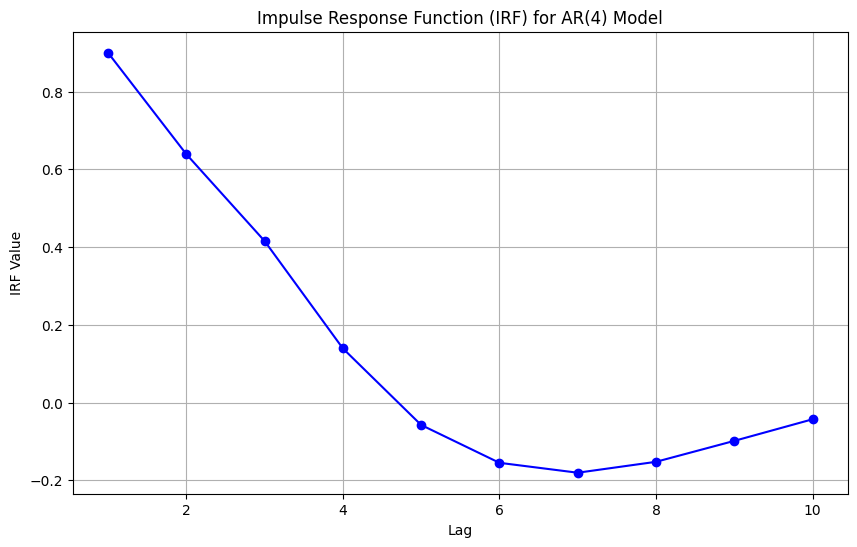

In [9]:
import matplotlib.pyplot as plt

# Plot the Impulse Response Function (IRF)
plt.figure(figsize=(10, 6))
plt.plot(range(1, horizon + 1), irf, marker='o', linestyle='-', color='b')
plt.title('Impulse Response Function (IRF) for AR(4) Model')
plt.xlabel('Lag')
plt.ylabel('IRF Value')
plt.grid(True)
plt.show()